# Baseline — OCR + regex sobre imagen completa

**Propósito:** evaluar la alternativa más simple al detector entrenado: correr OCR sobre la imagen completa y filtrar con regex. Sin detector, sin entrenamiento.

**Por qué importa para el paper:** es el baseline que responde *"¿realmente necesitamos YOLO?"*. Si esta baseline es competitiva en accuracy, perdemos parte de la justificación de YOLO. Si es lenta o tiene muchos falsos positivos, queda claro el aporte del detector.

**Métricas a reportar:** precision / recall / F1 / AUC-PR en test + latencia promedio (que será claramente peor que YOLO + OCR-sobre-crops).


## 1. Setup

In [1]:
from pathlib import Path
import json
import re
import time
from typing import Optional

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix,
    classification_report,
)

import torch
import easyocr

def pick_device():
    if torch.cuda.is_available():
        return 'cuda:0'
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

DEVICE = pick_device()
EASYOCR_GPU = torch.cuda.is_available()  # EasyOCR no soporta MPS
print('Device para PyTorch:', DEVICE)
print('EasyOCR usará GPU :', EASYOCR_GPU)


Device para PyTorch: cuda:0
EasyOCR usará GPU : True


## 2. Configuración

In [2]:
PROJECT_ROOT = Path.cwd()
DATA_ROOT    = PROJECT_ROOT / 'dataset_imagenes'
TEST_CSV     = DATA_ROOT / 'test' / 'test.csv'

WORK_DIR      = PROJECT_ROOT / 'work'
OUT_DIR       = WORK_DIR / 'baseline_ocr_regex'
OCR_CACHE_DIR = WORK_DIR / 'ocr_cache'
for d in (WORK_DIR, OUT_DIR, OCR_CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'baseline_ocr_regex'

# Iterar rápido durante el desarrollo: limitar imágenes procesadas.
# None = procesar todas (~3000 test images).
MAX_TEST_IMAGES = None

# Umbral de confianza para considerar un match del OCR como válido.
MIN_OCR_CONF = 0.30


## 3. Regex de detección de contactos

**Importante:** usamos *exactamente los mismos regex* que en `tp_final.ipynb` para que la comparación sea justa. Si esta baseline es mejor que YOLO, no es porque tenga acceso a información extra — es porque OCR-full-image captura cosas que YOLO no detecta (o porque las pseudo-labels de YOLO eran ruidosas).

In [3]:
EMAIL_RE = re.compile(r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}')
HANDLE_RE = re.compile(r'(?<![a-zA-Z0-9])@[a-zA-Z0-9_.]{3,30}')
SOCIAL_URL_RE = re.compile(
    r'(?:instagram\.com|facebook\.com|fb\.com|tiktok\.com|twitter\.com|x\.com|'
    r'youtu\.?be|wa\.me|api\.whatsapp\.com|t\.me)\/[a-zA-Z0-9_.\-/]+',
    re.IGNORECASE,
)
KEYWORD_RE = re.compile(
    r'\b(whats\s*app|whatsapp|wpp|wsp|wapp|llamanos|llam[aá]nos|consultanos|'
    r'cont[aá]ctanos|contacto|env[ií]anos|escribinos|cel(?:ular)?|tel(?:[eé]fono)?)\b',
    re.IGNORECASE,
)
PHONE_CANDIDATE_RE = re.compile(
    r'(?:\+?\d{1,3}[\s\-\.]?)?(?:\(?\d{2,4}\)?[\s\-\.]?){1,4}\d{3,4}'
)

def looks_like_phone(text: str) -> bool:
    digits = re.sub(r'\D', '', text)
    if not (8 <= len(digits) <= 15):
        return False
    if not PHONE_CANDIDATE_RE.search(text):
        return False
    if len(digits) > 13:
        return False
    return True

def classify_text(text: str) -> Optional[str]:
    """Devuelve clase de contacto o None. Prioridad: email > social > keyword > phone."""
    if EMAIL_RE.search(text):    return 'email'
    if SOCIAL_URL_RE.search(text) or HANDLE_RE.search(text): return 'social'
    if KEYWORD_RE.search(text):  return 'keyword'
    if looks_like_phone(text):   return 'phone'
    return None


## 4. OCR sobre imagen completa (con caché)

Procesa cada imagen del test set con EasyOCR. Guarda los resultados en `work/ocr_cache/test_ocr.json` para no tener que reprocesar.

**Atención CPU:** ~1-2s por imagen en CPU = 50-100 min para 3000 imágenes. Subir `MAX_TEST_IMAGES` gradualmente si querés validar primero.

In [4]:
ocr_reader = easyocr.Reader(['es', 'en'], gpu=EASYOCR_GPU)
print('EasyOCR listo. GPU activo:', EASYOCR_GPU)


EasyOCR listo. GPU activo: True


In [5]:
def quad_to_xyxy(quad):
    xs = [p[0] for p in quad]; ys = [p[1] for p in quad]
    return min(xs), min(ys), max(xs), max(ys)

def run_ocr_on_image(image_path: str, min_conf: float = MIN_OCR_CONF):
    img = cv2.imread(image_path)
    if img is None: return []
    h, w = img.shape[:2]
    results = ocr_reader.readtext(img)
    out = []
    for quad, text, conf in results:
        if conf < min_conf: continue
        x1, y1, x2, y2 = quad_to_xyxy(quad)
        out.append({
            'bbox': [int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))],
            'text': text,
            'conf': float(conf),
            'img_w': w, 'img_h': h,
        })
    return out


In [6]:
df_test = pd.read_csv(TEST_CSV)
df_test['abs_path'] = df_test['image_path'].apply(lambda p: str(DATA_ROOT / p))
if MAX_TEST_IMAGES is not None:
    df_test = df_test.head(MAX_TEST_IMAGES).reset_index(drop=True)
print(f'Test set: {len(df_test)} imágenes ({df_test.label.sum()} positivas, {df_test.label.mean()*100:.1f}%)')


Test set: 3000 imágenes (93 positivas, 3.1%)


In [7]:
OCR_CACHE_FILE = OCR_CACHE_DIR / 'test_ocr.json'

def load_cache(path):
    if path.exists():
        with open(path) as f: return json.load(f)
    return {}

def save_cache(cache, path):
    tmp = path.with_suffix('.tmp.json')
    with open(tmp, 'w') as f: json.dump(cache, f)
    tmp.replace(path)

ocr_cache = load_cache(OCR_CACHE_FILE)
print(f'Caché test existente: {len(ocr_cache)} imágenes')

to_process = df_test[~df_test['image_path'].isin(ocr_cache.keys())]
print(f'Faltan procesar: {len(to_process)}')

# Medimos latencia (incluso de los cached vs no cached) — necesaria para la tabla
latencies = []
BATCH_SAVE = 50
for i, row in enumerate(tqdm(to_process.itertuples(index=False), total=len(to_process))):
    t0 = time.time()
    try:
        ocr_cache[row.image_path] = run_ocr_on_image(row.abs_path)
    except Exception as e:
        print(f'Error en {row.image_path}: {e}')
        ocr_cache[row.image_path] = []
    latencies.append(time.time() - t0)
    if (i + 1) % BATCH_SAVE == 0:
        save_cache(ocr_cache, OCR_CACHE_FILE)
save_cache(ocr_cache, OCR_CACHE_FILE)

if latencies:
    print(f'\nLatencia OCR full-image: {np.mean(latencies)*1000:.1f} ms/imagen '
          f'(p50={np.percentile(latencies, 50)*1000:.1f}, '
          f'p95={np.percentile(latencies, 95)*1000:.1f})')
else:
    print('Todas las imágenes estaban en caché — no se midió latencia en este run.')


Caché test existente: 0 imágenes
Faltan procesar: 3000


  0%|          | 0/3000 [00:00<?, ?it/s]


Latencia OCR full-image: 91.5 ms/imagen (p50=42.5, p95=306.6)


## 5. Predicción por imagen

Para cada imagen:
- Iteramos sobre las regiones OCR detectadas.
- Aplicamos `classify_text` a cada texto.
- Si hay ≥1 match → `pred=1`.
- `score` = max OCR-confidence entre las regiones que matchearon (0 si ninguna).


In [8]:
def score_image(image_path: str):
    """Devuelve (score, pred_binary, n_matches, matched_classes)."""
    regions = ocr_cache.get(image_path, [])
    matched_confs = []
    matched_classes = []
    for r in regions:
        cls = classify_text(r['text'])
        if cls is not None:
            matched_confs.append(r['conf'])
            matched_classes.append(cls)
    if not matched_confs:
        return 0.0, 0, 0, []
    return max(matched_confs), 1, len(matched_confs), matched_classes

preds = df_test['image_path'].apply(score_image)
df_test['score']      = preds.apply(lambda x: x[0])
df_test['pred']       = preds.apply(lambda x: x[1])
df_test['n_matches']  = preds.apply(lambda x: x[2])
df_test['classes']    = preds.apply(lambda x: ','.join(x[3]) if x[3] else '')
df_test['model_name'] = MODEL_NAME

print(df_test[['label', 'pred', 'n_matches']].describe())
df_test.head()


             label         pred    n_matches
count  3000.000000  3000.000000  3000.000000
mean      0.031000     0.014667     0.019000
std       0.173347     0.120235     0.169259
min       0.000000     0.000000     0.000000
25%       0.000000     0.000000     0.000000
50%       0.000000     0.000000     0.000000
75%       0.000000     0.000000     0.000000
max       1.000000     1.000000     3.000000


,image_path,label,image_url,abs_path,score,pred,n_matches,classes,model_name
0,test/images/test_000000.jpg,0,https://http2.mlstatic.com/D_996681-MLA1007825...,C:\git\tp_vp2\dataset_imagenes\test\images\tes...,0.0,0,0,,baseline_ocr_regex
1,test/images/test_000001.jpg,0,https://http2.mlstatic.com/D_832062-MLC7437135...,C:\git\tp_vp2\dataset_imagenes\test\images\tes...,0.0,0,0,,baseline_ocr_regex
2,test/images/test_000002.jpg,0,https://http2.mlstatic.com/D_991225-MLB9807561...,C:\git\tp_vp2\dataset_imagenes\test\images\tes...,0.0,0,0,,baseline_ocr_regex
3,test/images/test_000003.jpg,0,https://http2.mlstatic.com/D_876523-MLB7015732...,C:\git\tp_vp2\dataset_imagenes\test\images\tes...,0.0,0,0,,baseline_ocr_regex
4,test/images/test_000004.jpg,0,https://http2.mlstatic.com/D_916251-MLB8911838...,C:\git\tp_vp2\dataset_imagenes\test\images\tes...,0.0,0,0,,baseline_ocr_regex


## 6. Métricas en test

In [9]:
y_true = df_test['label'].values
y_pred = df_test['pred'].values
scores = df_test['score'].values

print('=== Baseline OCR + regex (imagen completa) ===')
print(f'Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}')
print(f'Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}')
print(f'F1       : {f1_score(y_true, y_pred, zero_division=0):.4f}')
try:
    print(f'AUC-PR   : {average_precision_score(y_true, scores):.4f}')
    print(f'AUC-ROC  : {roc_auc_score(y_true, scores):.4f}')
except ValueError as e:
    print(f'AUC      : no calculable ({e})')

print('\nMatriz de confusión:')
cm = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(cm,
                   index=['actual=0', 'actual=1'],
                   columns=['pred=0', 'pred=1']))

print('\nClassification report:')
print(classification_report(y_true, y_pred,
                            target_names=['no_contact', 'contact'],
                            zero_division=0))

print('\nDistribución de clases matcheadas:')
from collections import Counter
cls_counter = Counter()
for c in df_test['classes']:
    if c:
        for cls in c.split(','):
            cls_counter[cls] += 1
for cls, n in cls_counter.most_common():
    print(f'  {cls:10s}: {n}')


=== Baseline OCR + regex (imagen completa) ===
Precision: 0.4091
Recall   : 0.1935
F1       : 0.2628
AUC-PR   : 0.1455
AUC-ROC  : 0.5925

Matriz de confusión:
          pred=0  pred=1
actual=0    2881      26
actual=1      75      18

Classification report:
              precision    recall  f1-score   support

  no_contact       0.97      0.99      0.98      2907
     contact       0.41      0.19      0.26        93

    accuracy                           0.97      3000
   macro avg       0.69      0.59      0.62      3000
weighted avg       0.96      0.97      0.96      3000


Distribución de clases matcheadas:
  phone     : 26
  social    : 24
  keyword   : 7


## 7. Guardar predicciones para comparación

Schema: `image_path, label, score, pred, model_name`. Compatible con `comparison.ipynb`.

In [10]:
out_path = OUT_DIR / 'test_predictions.csv'
df_test[['image_path', 'label', 'score', 'pred', 'model_name']].to_csv(out_path, index=False)
print(f'Guardado: {out_path}  ({len(df_test)} filas)')

# Latencia summary para el paper
if latencies:
    latency_stats = {
        'model_name':    MODEL_NAME,
        'n_images':      len(latencies),
        'mean_ms':       float(np.mean(latencies) * 1000),
        'p50_ms':        float(np.percentile(latencies, 50) * 1000),
        'p95_ms':        float(np.percentile(latencies, 95) * 1000),
        'device':        DEVICE,
        'easyocr_gpu':   EASYOCR_GPU,
    }
    with open(OUT_DIR / 'latency_stats.json', 'w') as f:
        json.dump(latency_stats, f, indent=2)
    print('Latency stats:', latency_stats)


Guardado: C:\git\tp_vp2\work\baseline_ocr_regex\test_predictions.csv  (3000 filas)
Latency stats: {'model_name': 'baseline_ocr_regex', 'n_images': 3000, 'mean_ms': 91.52150670687358, 'p50_ms': 42.467594146728516, 'p95_ms': 306.63026571273747, 'device': 'cuda:0', 'easyocr_gpu': True}


## 8. Inspección visual de errores

=== Top 6 falsos positivos (label=0 pero predijimos 1) ===


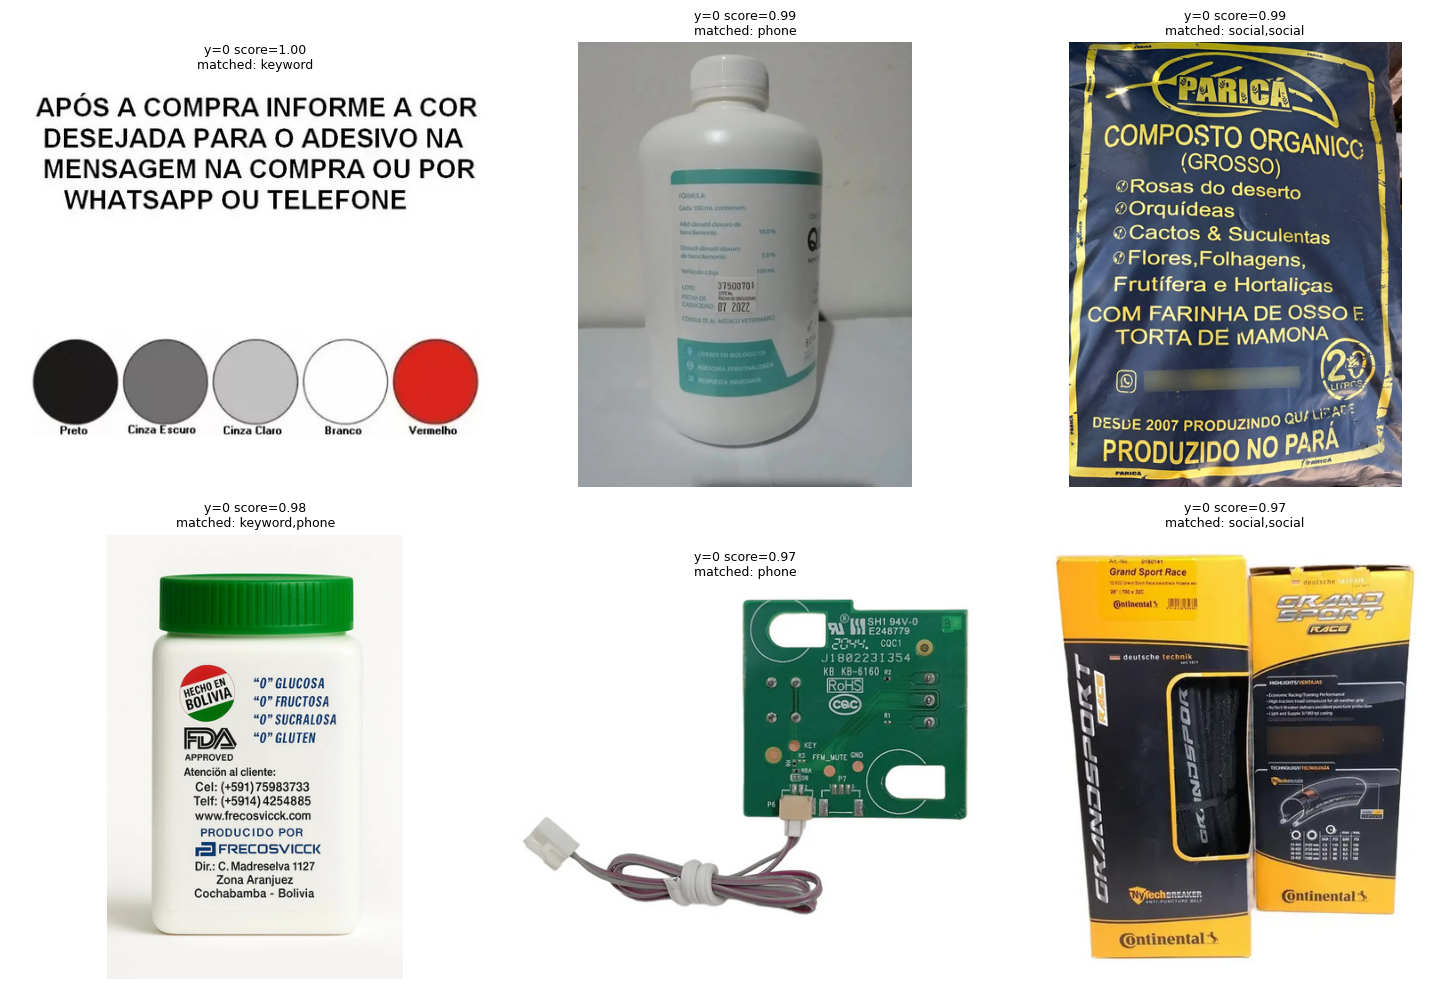


=== Falsos negativos (label=1 pero predijimos 0) ===


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


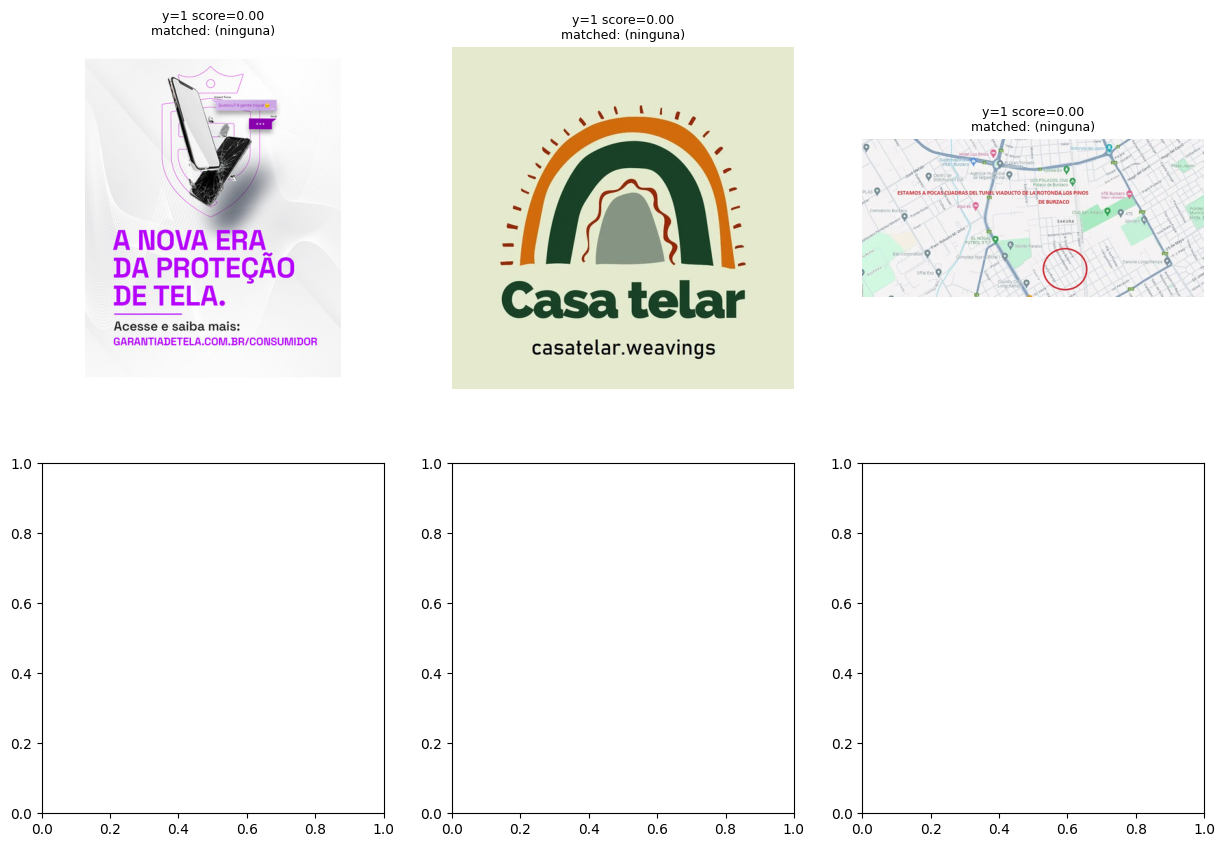

In [11]:
def show_errors(df, error_type, n=6):
    if error_type == 'fp':
        subset = df[(df.label == 0) & (df.pred == 1)].sort_values('score', ascending=False)
    elif error_type == 'fn':
        subset = df[(df.label == 1) & (df.pred == 0)]
    else:
        raise ValueError
    subset = subset.head(n)
    if len(subset) == 0:
        print(f'No hay ejemplos de {error_type}'); return
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, (_, row) in zip(axes.flatten(), subset.iterrows()):
        img = cv2.cvtColor(cv2.imread(row['abs_path']), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.axis('off')
        ax.set_title(f"y={row['label']} score={row['score']:.2f}\n"
                     f"matched: {row['classes'] or '(ninguna)'}", fontsize=9)
    for ax in axes.flatten()[len(subset):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

print('=== Top 6 falsos positivos (label=0 pero predijimos 1) ===')
show_errors(df_test, 'fp')
print('\n=== Falsos negativos (label=1 pero predijimos 0) ===')
show_errors(df_test, 'fn')
